In [1]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import pandas as pd
from src.environment import HotelPricingEnv
from src.baseline_agents import (fixed_price_agent,random_price_agent,discount_agent)

In [3]:
env = HotelPricingEnv()

In [4]:
import numpy as np

def evaluate_agent(agent_name, episodes=50):
    revenues = []
    rooms_sold = []
    avg_prices = []

    for _ in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        total_rooms = 0
        price_history = []
        done = False

        while not done:
            if agent_name == "Fixed":
                action = fixed_price_agent()
            elif agent_name == "Random":
                action = random_price_agent()
            elif agent_name == "Discount":
                action = discount_agent(env.day)

            state, reward, done, _, info = env.step(action)
            total_reward += reward
            total_rooms += info["rooms_sold"]
            price_history.append(info["price"])

        revenues.append(total_reward)
        rooms_sold.append(total_rooms)
        avg_prices.append(np.mean(price_history))

    return {
        "Strategy": agent_name,
        "Average Revenue": np.mean(revenues),
        "Average Rooms Sold": np.mean(rooms_sold),
        "Average Occupancy (%)": np.mean(rooms_sold) / 50 * 100,
        "Average Price": np.mean(avg_prices),
        "Episodes": episodes
    }

In [5]:
results = pd.DataFrame([
    evaluate_agent("Fixed"),
    evaluate_agent("Random"),
    evaluate_agent("Discount")
])
results

,Strategy,Average Revenue,Average Rooms Sold,Average Occupancy (%),Average Price,Episodes
0,Fixed,3638.5,38.30,76.60,120.000000,50
1,Random,3202.1,37.74,75.48,119.493333,50
2,Discount,3051.5,36.58,73.16,126.666667,50


In [6]:
results.to_csv(r"..\data\processed\baseline_results.csv",index=False)
print("Baseline results saved.")

Baseline results saved.


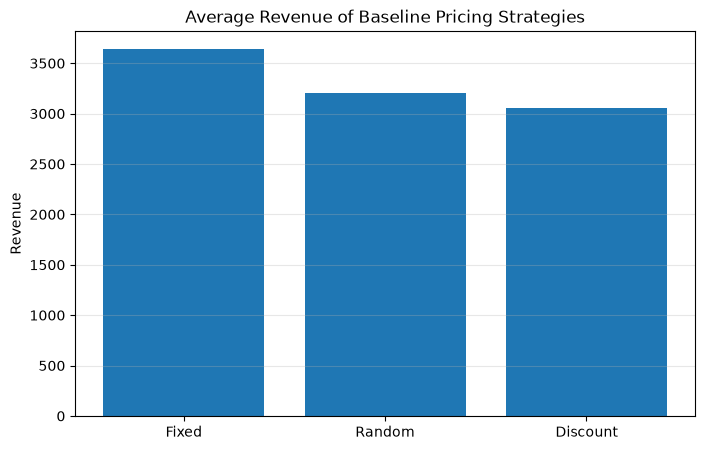

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Strategy"],results["Average Revenue"])

plt.title("Average Revenue of Baseline Pricing Strategies")

plt.ylabel("Revenue")

plt.grid(axis="y", alpha=0.3)

plt.show()

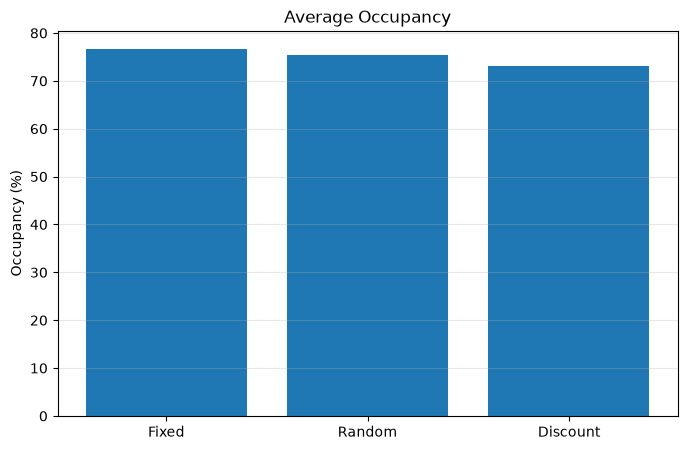

In [8]:
plt.figure(figsize=(8,5))

plt.bar(results["Strategy"],results["Average Occupancy (%)"])

plt.title("Average Occupancy")

plt.ylabel("Occupancy (%)")

plt.grid(axis="y", alpha=0.3)

plt.show()